# 0. Importing Necessary Packages

In [36]:
import numpy as np
import os
from matplotlib import pyplot as plt
from astropy.io import fits
import pandas as pd
from acstools import acszpt
from reproject import reproject_interp

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
%matplotlib inline

# Pandas configuration
pd.set_option('display.max_columns', None)




In [37]:
def galextcor(data, wavelength):
    EBV = 0.1893
    coeffs = {
        "F390W": 4.514,
        "F435W": 4.117,
        "F475W": 3.747,
        "F555W": 3.242,
        "F606W": 2.929,
        "F625W": 2.671,
        "F775W": 2.018,
        "F814W": 1.847,
        "F850LP": 1.473,
        "F105W": 1.015,
        "F110W": 0.876,
        "F125W": 0.757,
        "F140W": 0.609,
        "F160W": 0.470
    }
    coef = coeffs.get(wavelength)
    if coef is not None:
        data['mag_iso'] = data['mag_iso'] - (coef * EBV)
        return data
    else:
        print("wrong input")


class matchingsexcat:
    """
    Matches SExtractor catalog sources to reference catalog within a fixed tolerance.
    """
    def __init__(self, dat_sex, dat_catalog):
        from astropy.coordinates import SkyCoord, match_coordinates_sky
        import astropy.units as u

        tol = 0.4 / 3600  # tolerance in degrees
        ra_s, dec_s = dat_sex['ra'], dat_sex['dec']
        ra_c, dec_c = dat_catalog['RA'], dat_catalog['Dec']
        src = SkyCoord(ra=ra_s * u.degree, dec=dec_s * u.degree)
        cat = SkyCoord(ra=ra_c * u.degree, dec=dec_c * u.degree)
        idx, sep2d, dist3d = match_coordinates_sky(src, cat, nthneighbor=1, storekdtree='kdtree_sky')

        matched = sep2d.value < tol
        self.n_mch = np.sum(matched)
        self.idx_cat = idx[matched]
        self.idx_src = np.where(matched)[0]

    def matchedsex(self, dat_sex):
        return dat_sex[self.idx_src]

    def matchedsex_index(self):
        return self.idx_src

    def matchedcat(self, dat_catalog):
        return dat_catalog[self.idx_cat]

    def matchedcat_index(self):
        return self.idx_cat

    def matchedsize(self):
        return self.n_mch


class matchingsexsex:
    """
    Matches two SExtractor output catalogs to each other within a fixed tolerance.
    """
    def __init__(self, dat_sex1, dat_sex2):
        from astropy.coordinates import SkyCoord, match_coordinates_sky
        import astropy.units as u

        tol = 0.1 / 3600  # tolerance in degrees
        ra1, dec1 = dat_sex1['ra'], dat_sex1['dec']
        ra2, dec2 = dat_sex2['ra'], dat_sex2['dec']
        src = SkyCoord(ra=ra1 * u.degree, dec=dec1 * u.degree)
        cat = SkyCoord(ra=ra2 * u.degree, dec=dec2 * u.degree)
        idx, sep2d, dist3d = match_coordinates_sky(src, cat, nthneighbor=1, storekdtree='kdtree_sky')

        matched = sep2d.value < tol
        self.n_mch = np.sum(matched)
        self.idx_cat = idx[matched]
        self.idx_src = np.where(matched)[0]

    def matchedsex(self, dat_sex1):
        return dat_sex1[self.idx_src]

    def matchedsex_index(self):
        return self.idx_src

    def matchedcat(self, dat_sex2):
        return dat_sex2[self.idx_cat]

    def matchedcat_index(self):
        return self.idx_cat

    def matchedsize(self):
        return self.n_mch


# 1. F105W-F160W

In [38]:
# =============================================================================
# Column Names
# =============================================================================
cat_colnames = [
    'id', 'RA', 'Dec', 'x', 'y', 'fwhm', 'area', 'stel', 'ell', 'theta', 'nf5sig', 'nfobs',
    'f435w_mag', 'f435w_magerr', 'f435w_flux', 'f435w_fluxerr', 'f435w_fluxnJy', 'f435w_fluxnJyerr', 'f435w_sig',
    'f606w_mag', 'f606w_magerr', 'f606w_flux', 'f606w_fluxerr', 'f606w_fluxnJy', 'f606w_fluxnJyerr', 'f606w_sig',
    'f814w_mag', 'f814w_magerr', 'f814w_flux', 'f814w_fluxerr', 'f814w_fluxnJy', 'f814w_fluxnJyerr', 'f814w_sig',
    'f105w_mag', 'f105w_magerr', 'f105w_flux', 'f105w_fluxerr', 'f105w_fluxnJy', 'f105w_fluxnJyerr', 'f105w_sig',
    'f125w_mag', 'f125w_magerr', 'f125w_flux', 'f125w_fluxerr', 'f125w_fluxnJy', 'f125w_fluxnJyerr', 'f125w_sig',
    'f140w_mag', 'f140w_magerr', 'f140w_flux', 'f140w_fluxerr', 'f140w_fluxnJy', 'f140w_fluxnJyerr', 'f140w_sig',
    'f160w_mag', 'f160w_magerr', 'f160w_flux', 'f160w_fluxerr', 'f160w_fluxnJy', 'f160w_fluxnJyerr', 'f160w_sig',
    'bright_mag', 'bright_magerr', 'zb', 'zbmin', 'zbmax', 'tb', 'odds', 'chisq', 'chisq2', 'M0', 'zml', 'tml'
]

sex_colnames = [
    'x', 'y', 'num', 'mag_auto', 'merr_auto', 'mag_iso', 'merr_iso', 'mag_isocor', 'magerr_isocor', 'kron',
    'backgr', 'ra', 'dec', 'a', 'b', 'theta', 'mu0', 'flag', 'fwhm', 'flxrad', 'cl'
]

# =============================================================================
# Load Data
# =============================================================================
dat_cat = np.genfromtxt(
    '../DATA/hlsp_relics_hst_wfc3ir_smacs0723m73_multi_v1_cat.txt',
    dtype=None, encoding='ascii', names=cat_colnames
)

bands = ["F105W", "F160W"]
bands_catread = ["f105w", "f160w"]

dat_0 = np.genfromtxt(
    f'../RESULT/60mas/F105W-F160W/Threshold_Low/{bands[0]}.cat',
    dtype=None, encoding='ascii', names=sex_colnames
)
dat_1 = np.genfromtxt(
    f'../RESULT/60mas/F105W-F160W/Threshold_Low/{bands[1]}.cat',
    dtype=None, encoding='ascii', names=sex_colnames
)

# Apply galactic extinction correction
dat_0 = galextcor(dat_0, "F105W")
dat_1 = galextcor(dat_1, "F160W")

# =============================================================================
# Direct Matching: SExtractor <-> Catalog
# =============================================================================
# Key fix: use index methods instead of comparing structured arrays!
matcher = matchingsexcat(dat_0, dat_cat)
idx_src = matcher.matchedsex_index()   # matched SExtractor indices
idx_cat = matcher.matchedcat_index()   # matched Catalog indices

matched_F105W = dat_0[idx_src]
matched_F160W = dat_1[idx_src]
matched_Cat   = dat_cat[idx_cat]

print(f"Total matched: {len(idx_src)}")

# =============================================================================
# Separate Point / Extended Sources
# =============================================================================
# Stellarity > 0.6 = point source (star-like)
# Stellarity < 0.6 = extended source (galaxy-like)
point_sel_src = dat_0['cl'] > 0.6
ext_sel_src   = dat_0['cl'] < 0.6
point_sel_cat = dat_cat['stel'] > 0.6
ext_sel_cat   = dat_cat['stel'] < 0.6

dat_0_point = dat_0[point_sel_src]
dat_0_ext   = dat_0[ext_sel_src]
dat_1_point = dat_1[point_sel_src]
dat_1_ext   = dat_1[ext_sel_src]
dat_cat_point = dat_cat[point_sel_cat]
dat_cat_ext   = dat_cat[ext_sel_cat]

# =============================================================================
# Matching by Source Type
# =============================================================================
matcher_point = matchingsexcat(dat_0_point, dat_cat_point)
matcher_ext   = matchingsexcat(dat_0_ext, dat_cat_ext)

idx_src_point = matcher_point.matchedsex_index()
idx_src_ext   = matcher_ext.matchedsex_index()
idx_cat_point = matcher_point.matchedcat_index()
idx_cat_ext   = matcher_ext.matchedcat_index()

matched_F105W_point = dat_0_point[idx_src_point]
matched_F105W_ext   = dat_0_ext[idx_src_ext]
matched_F160W_point = dat_1_point[idx_src_point]
matched_F160W_ext   = dat_1_ext[idx_src_ext]
matched_cat_point   = dat_cat_point[idx_cat_point]
matched_cat_ext     = dat_cat_ext[idx_cat_ext]

print(f"Point source matched: {len(matched_F105W_point)}")
print(f"Extended source matched: {len(matched_F105W_ext)}")

# =============================================================================
# Find Unmatched Sources (efficient way using np.setdiff1d)
# =============================================================================
idx_src_unmatched = np.setdiff1d(np.arange(len(dat_0)), idx_src)
idx_cat_unmatched = np.setdiff1d(np.arange(len(dat_cat)), idx_cat)

unmatched_F105W = dat_0[idx_src_unmatched]
unmatched_F160W = dat_1[idx_src_unmatched]
unmatched_Cat   = dat_cat[idx_cat_unmatched]

print(f"SExtractor unmatched: {len(unmatched_F105W)}")
print(f"Catalog unmatched: {len(unmatched_Cat)}")


Total matched: 1436
Point source matched: 220
Extended source matched: 976
SExtractor unmatched: 1047
Catalog unmatched: 134


In [39]:
%matplotlib inline

## 1) Raw Data

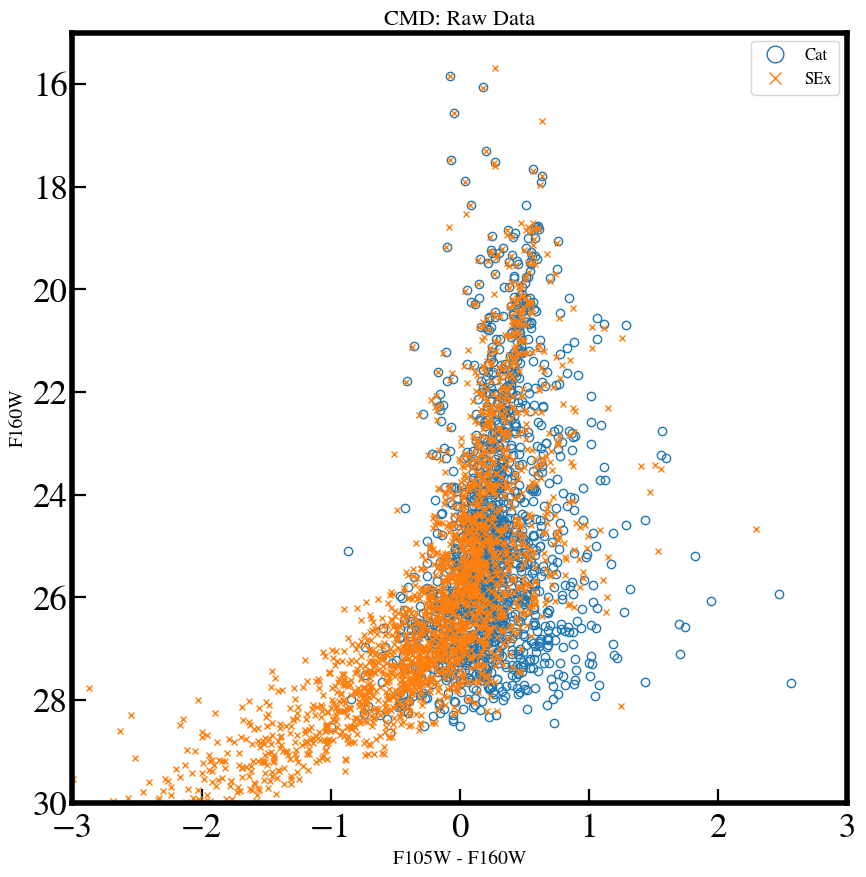

In [40]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# CMD: Raw Data (SExtractor vs Catalog)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Catalog - blue open circle
ax.plot(dat_cat[f'{bands_catread[0]}_mag'] - dat_cat[f'{bands_catread[1]}_mag'],
        dat_cat[f'{bands_catread[1]}_mag'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
# SExtractor - orange x
ax.plot(dat_0['mag_iso'] - dat_1['mag_iso'], dat_1['mag_iso'],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')

ax.set_title('CMD: Raw Data', fontsize=16)
ax.set_xlabel(f'{bands[0]} - {bands[1]}', fontsize=14)
ax.set_ylabel(f'{bands[1]}', fontsize=14)
ax.set_xlim([-3, 3])
ax.set_ylim([30, 15])
ax.legend(markerscale=2, fontsize=12, handler_map=handler_map)
plt.show()


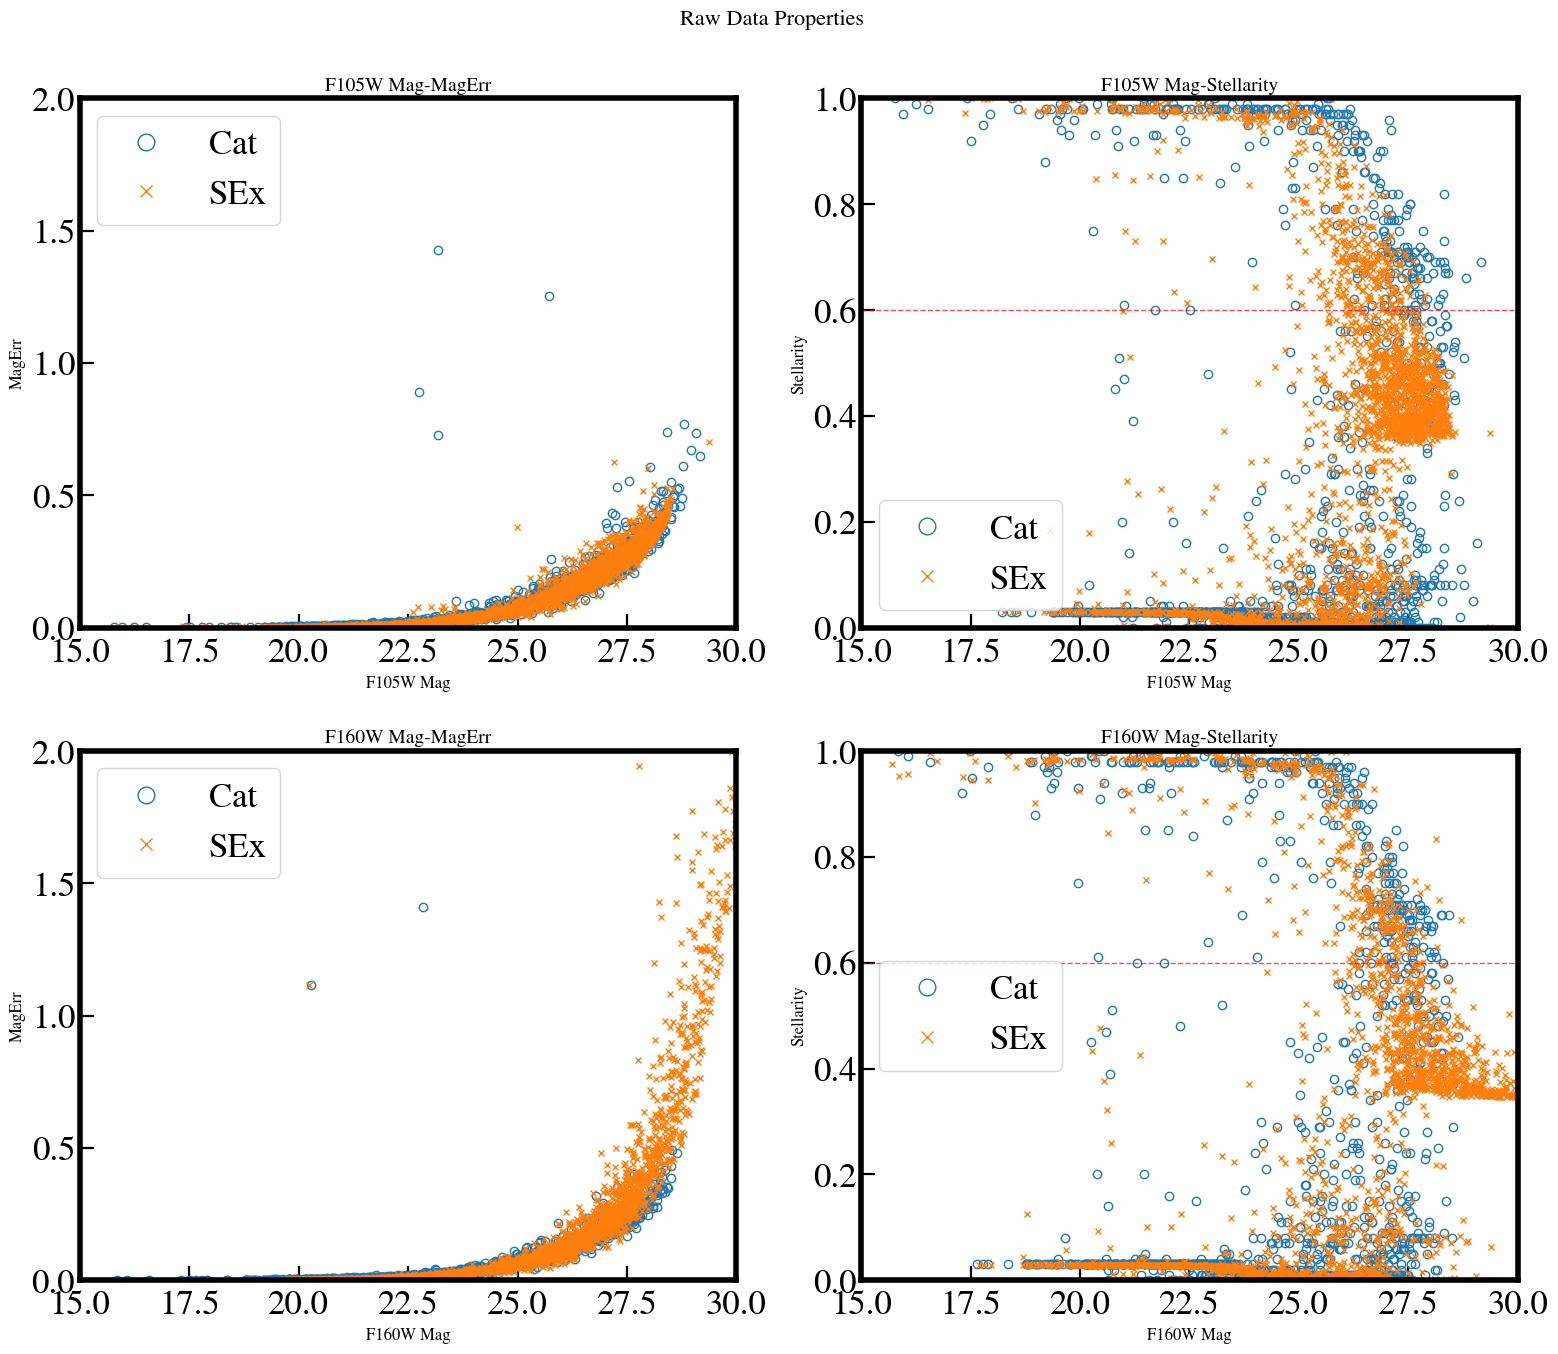

In [41]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Raw Data Properties: Mag-MagErr & Mag-Stellarity
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Raw Data Properties', fontsize=16)

# -----------------------------------------------------------------------------
# (0,0) F105W Mag-MagErr
# -----------------------------------------------------------------------------
ax[0, 0].plot(dat_cat[f'{bands_catread[0]}_mag'], dat_cat[f'{bands_catread[0]}_magerr'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[0, 0].plot(dat_0['mag_iso'], dat_0['merr_iso'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0, 0].set_title(f'{bands[0]} Mag-MagErr', fontsize=14)
ax[0, 0].set_xlabel(f'{bands[0]} Mag', fontsize=12)
ax[0, 0].set_ylabel('MagErr', fontsize=12)
ax[0, 0].set_xlim([15, 30])
ax[0, 0].set_ylim([0, 2])
ax[0, 0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (0,1) F105W Mag-Stellarity
# -----------------------------------------------------------------------------
ax[0, 1].plot(dat_cat[f'{bands_catread[0]}_mag'], dat_cat['stel'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[0, 1].plot(dat_0['mag_iso'], dat_0['cl'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0, 1].set_title(f'{bands[0]} Mag-Stellarity', fontsize=14)
ax[0, 1].set_xlabel(f'{bands[0]} Mag', fontsize=12)
ax[0, 1].set_ylabel('Stellarity', fontsize=12)
ax[0, 1].set_xlim([15, 30])
ax[0, 1].set_ylim([0, 1])
ax[0, 1].axhline(0.6, ls='--', color='red', lw=1, alpha=0.7)
ax[0, 1].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1,0) F160W Mag-MagErr
# -----------------------------------------------------------------------------
ax[1, 0].plot(dat_cat[f'{bands_catread[1]}_mag'], dat_cat[f'{bands_catread[1]}_magerr'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[1, 0].plot(dat_1['mag_iso'], dat_1['merr_iso'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1, 0].set_title(f'{bands[1]} Mag-MagErr', fontsize=14)
ax[1, 0].set_xlabel(f'{bands[1]} Mag', fontsize=12)
ax[1, 0].set_ylabel('MagErr', fontsize=12)
ax[1, 0].set_xlim([15, 30])
ax[1, 0].set_ylim([0, 2])
ax[1, 0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1,1) F160W Mag-Stellarity
# -----------------------------------------------------------------------------
ax[1, 1].plot(dat_cat[f'{bands_catread[1]}_mag'], dat_cat['stel'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[1, 1].plot(dat_1['mag_iso'], dat_1['cl'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1, 1].set_title(f'{bands[1]} Mag-Stellarity', fontsize=14)
ax[1, 1].set_xlabel(f'{bands[1]} Mag', fontsize=12)
ax[1, 1].set_ylabel('Stellarity', fontsize=12)
ax[1, 1].set_xlim([15, 30])
ax[1, 1].set_ylim([0, 1])
ax[1, 1].axhline(0.6, ls='--', color='red', lw=1, alpha=0.7)
ax[1, 1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


## 2) Matched Source

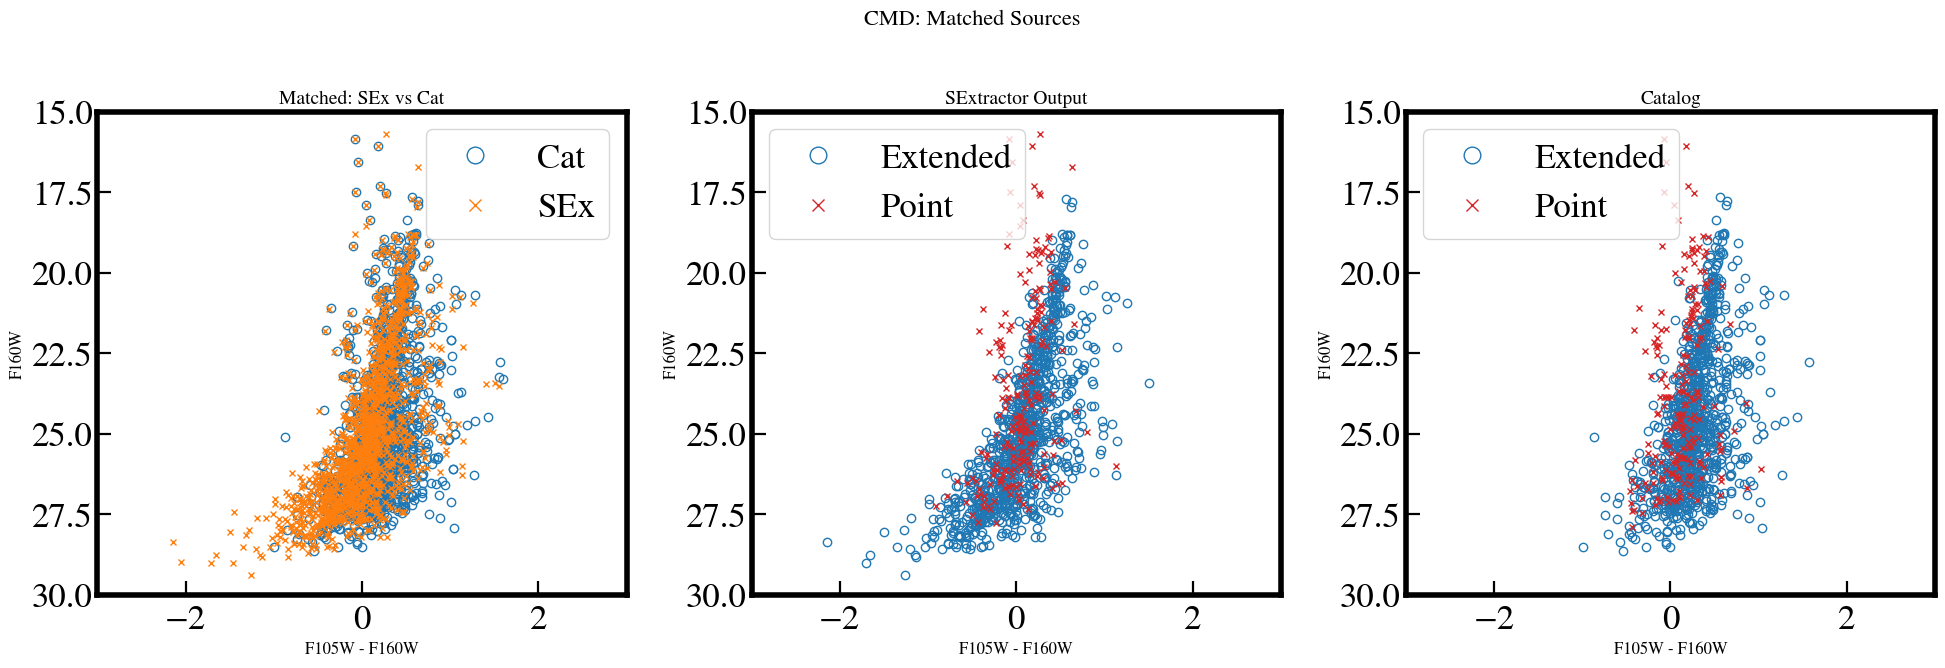

In [42]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# CMD: Matched Sources Analysis
# =============================================================================
fig, ax = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('CMD: Matched Sources', fontsize=16)

# -----------------------------------------------------------------------------
# (0) Matched: SExtractor vs Catalog
# -----------------------------------------------------------------------------
ax[0].plot(matched_Cat[f'{bands_catread[0]}_mag'] - matched_Cat[f'{bands_catread[1]}_mag'],
           matched_Cat[f'{bands_catread[1]}_mag'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[0].plot(matched_F105W['mag_iso'] - matched_F160W['mag_iso'],
           matched_F160W['mag_iso'],
           marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0].set_title('Matched: SEx vs Cat', fontsize=14)
ax[0].set_xlabel(f'{bands[0]} - {bands[1]}', fontsize=12)
ax[0].set_ylabel(f'{bands[1]}', fontsize=12)
ax[0].set_xlim([-3, 3])
ax[0].set_ylim([30, 15])
ax[0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1) SExtractor: Point vs Extended
# -----------------------------------------------------------------------------
ax[1].plot(matched_F105W_ext['mag_iso'] - matched_F160W_ext['mag_iso'],
           matched_F160W_ext['mag_iso'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Extended')
ax[1].plot(matched_F105W_point['mag_iso'] - matched_F160W_point['mag_iso'],
           matched_F160W_point['mag_iso'],
           marker='x', ms=4, color='tab:red', linestyle='None', label='Point')
ax[1].set_title('SExtractor Output', fontsize=14)
ax[1].set_xlabel(f'{bands[0]} - {bands[1]}', fontsize=12)
ax[1].set_ylabel(f'{bands[1]}', fontsize=12)
ax[1].set_xlim([-3, 3])
ax[1].set_ylim([30, 15])
ax[1].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (2) Catalog: Point vs Extended
# -----------------------------------------------------------------------------
ax[2].plot(matched_cat_ext[f'{bands_catread[0]}_mag'] - matched_cat_ext[f'{bands_catread[1]}_mag'],
           matched_cat_ext[f'{bands_catread[1]}_mag'],
           marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Extended')
ax[2].plot(matched_cat_point[f'{bands_catread[0]}_mag'] - matched_cat_point[f'{bands_catread[1]}_mag'],
           matched_cat_point[f'{bands_catread[1]}_mag'],
           marker='x', ms=4, color='tab:red', linestyle='None', label='Point')
ax[2].set_title('Catalog', fontsize=14)
ax[2].set_xlabel(f'{bands[0]} - {bands[1]}', fontsize=12)
ax[2].set_ylabel(f'{bands[1]}', fontsize=12)
ax[2].set_xlim([-3, 3])
ax[2].set_ylim([30, 15])
ax[2].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


In the above plot, the first panel shows the result of direct matching of all sources (Matched Source).

For panels 2 and 3, the Matched Source is shown by matching point sources to point sources, and extended sources to extended sources.

In [43]:
print(f"size of catalog: {np.size(dat_cat)}")
print(f"size of matched catalog: {np.size(matched_Cat)}")
print(f"size of unmatched catalog: {np.size(unmatched_Cat)}")
print(f"size of sextractor output: {np.size(dat_0)}")
print(f"size of matched sextractor output: {np.size(matched_F105W)}")
print(f"size of unmatched sextractor output: {np.size(unmatched_F105W)}")


size of catalog: 1475
size of matched catalog: 1436
size of unmatched catalog: 134
size of sextractor output: 2483
size of matched sextractor output: 1436
size of unmatched sextractor output: 1047


<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:72: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:72: SyntaxWarning: invalid escape sequence '\D'
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_34548/965445658.py:22: SyntaxWarning: invalid escape sequence '\D'
  ax[0, 0].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_34548/965445658.py:38: SyntaxWarning: invalid escape sequence '\D'
  ax[0, 1].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_34548/965445658.py:55: SyntaxWarning: invalid escape sequence '\D'
  ax[1, 0].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
/var/folders/8j/r5cxq2xj3

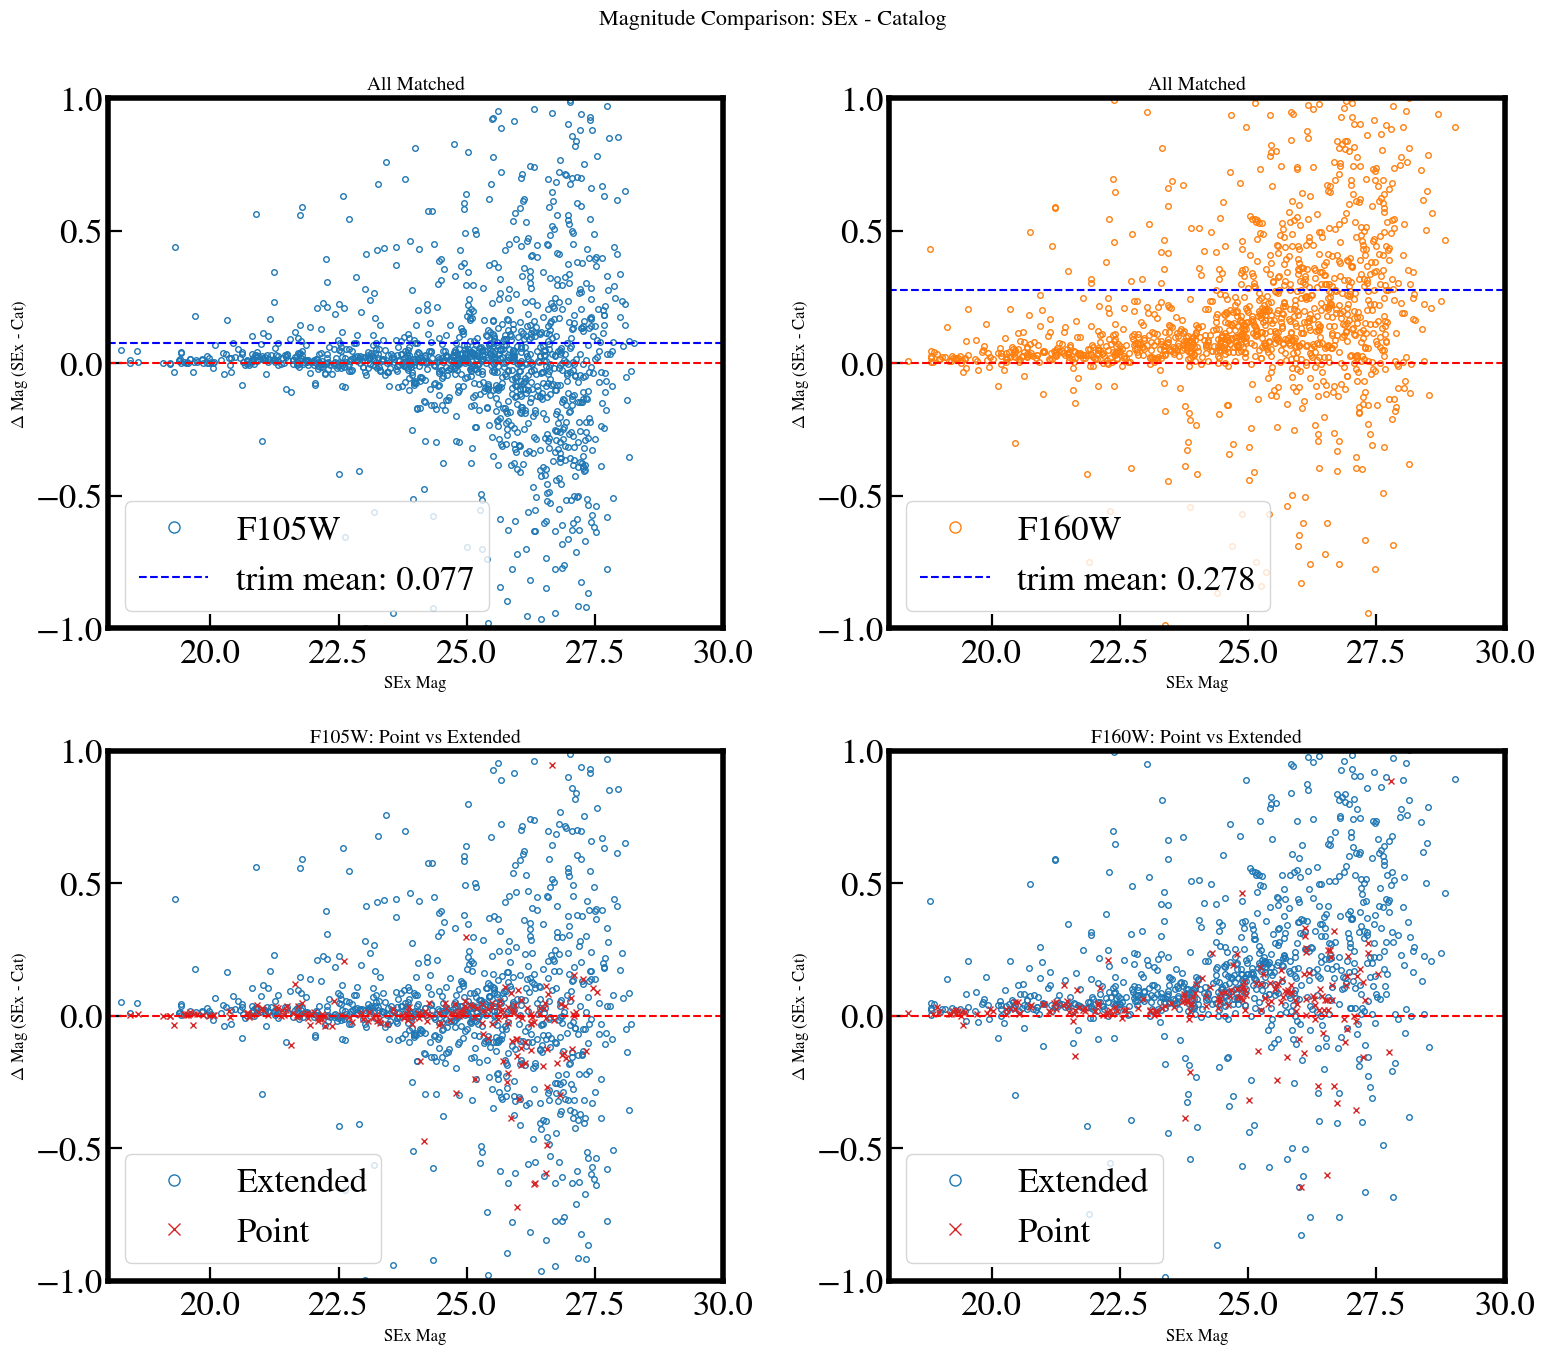

In [44]:
from matplotlib.legend_handler import HandlerLine2D
from scipy import stats
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Magnitude Difference: SExtractor - Catalog
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Magnitude Comparison: SEx - Catalog', fontsize=16)

# -----------------------------------------------------------------------------
# (0,0) F105W - All Matched
# -----------------------------------------------------------------------------
delta_mag_105 = matched_F105W['mag_iso'] - matched_Cat[f'{bands_catread[0]}_mag']
ax[0, 0].plot(matched_F105W['mag_iso'], delta_mag_105,
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label=bands[0])
ax[0, 0].axhline(0, ls='--', color='red', lw=1.5)
ax[0, 0].axhline(stats.trim_mean(delta_mag_105, 0.05), ls='--', color='blue', lw=1.5, 
                 label=f'trim mean: {stats.trim_mean(delta_mag_105, 0.05):.3f}')
ax[0, 0].set_title('All Matched', fontsize=14)
ax[0, 0].set_xlabel('SEx Mag', fontsize=12)
ax[0, 0].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
ax[0, 0].set_xlim([18, 30])
ax[0, 0].set_ylim([-1, 1])
ax[0, 0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (0,1) F160W - All Matched
# -----------------------------------------------------------------------------
delta_mag_160 = matched_F160W['mag_iso'] - matched_Cat[f'{bands_catread[1]}_mag']
ax[0, 1].plot(matched_F160W['mag_iso'], delta_mag_160,
              marker='o', ms=4, mfc='none', mec='tab:orange', linestyle='None', label=bands[1])
ax[0, 1].axhline(0, ls='--', color='red', lw=1.5)
ax[0, 1].axhline(stats.trim_mean(delta_mag_160, 0.05), ls='--', color='blue', lw=1.5,
                 label=f'trim mean: {stats.trim_mean(delta_mag_160, 0.05):.3f}')
ax[0, 1].set_title('All Matched', fontsize=14)
ax[0, 1].set_xlabel('SEx Mag', fontsize=12)
ax[0, 1].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
ax[0, 1].set_xlim([18, 30])
ax[0, 1].set_ylim([-1, 1])
ax[0, 1].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1,0) F105W - Point vs Extended
# -----------------------------------------------------------------------------
ax[1, 0].plot(matched_F105W_ext['mag_iso'], 
              matched_F105W_ext['mag_iso'] - matched_cat_ext[f'{bands_catread[0]}_mag'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='Extended')
ax[1, 0].plot(matched_F105W_point['mag_iso'], 
              matched_F105W_point['mag_iso'] - matched_cat_point[f'{bands_catread[0]}_mag'],
              marker='x', ms=4, color='tab:red', linestyle='None', label='Point')
ax[1, 0].axhline(0, ls='--', color='red', lw=1.5)
ax[1, 0].set_title(f'{bands[0]}: Point vs Extended', fontsize=14)
ax[1, 0].set_xlabel('SEx Mag', fontsize=12)
ax[1, 0].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
ax[1, 0].set_xlim([18, 30])
ax[1, 0].set_ylim([-1, 1])
ax[1, 0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1,1) F160W - Point vs Extended
# -----------------------------------------------------------------------------
ax[1, 1].plot(matched_F160W_ext['mag_iso'], 
              matched_F160W_ext['mag_iso'] - matched_cat_ext[f'{bands_catread[1]}_mag'],
              marker='o', ms=4, mfc='none', mec='tab:blue', linestyle='None', label='Extended')
ax[1, 1].plot(matched_F160W_point['mag_iso'], 
              matched_F160W_point['mag_iso'] - matched_cat_point[f'{bands_catread[1]}_mag'],
              marker='x', ms=4, color='tab:red', linestyle='None', label='Point')
ax[1, 1].axhline(0, ls='--', color='red', lw=1.5)
ax[1, 1].set_title(f'{bands[1]}: Point vs Extended', fontsize=14)
ax[1, 1].set_xlabel('SEx Mag', fontsize=12)
ax[1, 1].set_ylabel('$\Delta$ Mag (SEx - Cat)', fontsize=12)
ax[1, 1].set_xlim([18, 30])
ax[1, 1].set_ylim([-1, 1])
ax[1, 1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


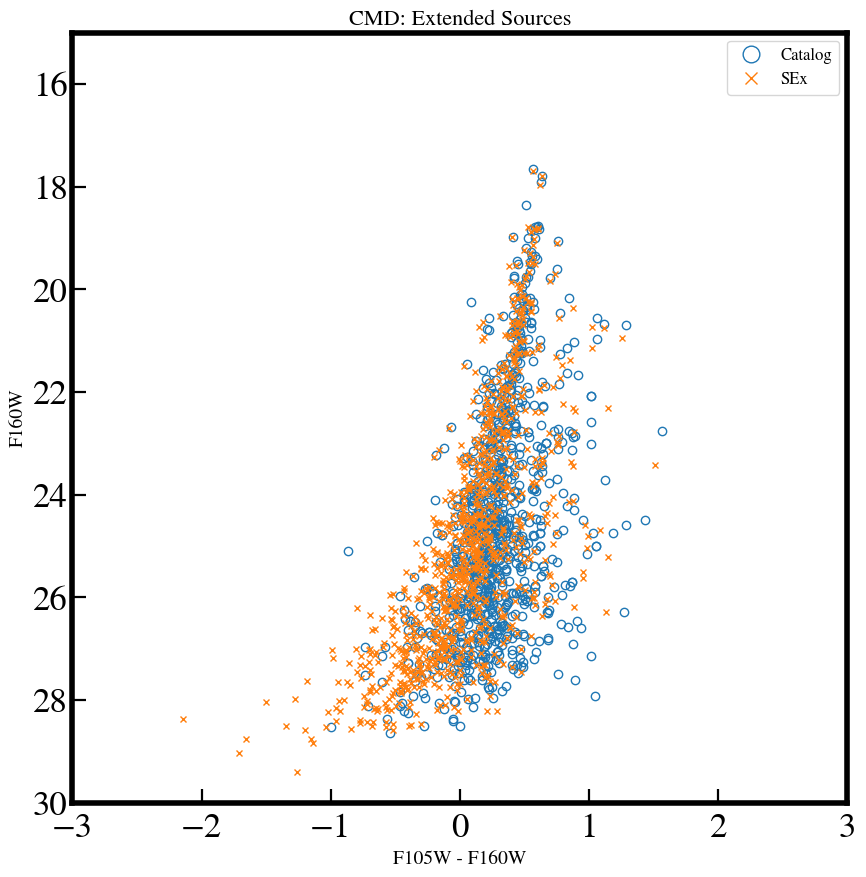

In [45]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# CMD: Extended Sources Only
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(matched_cat_ext[f'{bands_catread[0]}_mag'] - matched_cat_ext[f'{bands_catread[1]}_mag'],
        matched_cat_ext[f'{bands_catread[1]}_mag'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Catalog')
ax.plot(matched_F105W_ext['mag_iso'] - matched_F160W_ext['mag_iso'],
        matched_F160W_ext['mag_iso'],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')

ax.set_title('CMD: Extended Sources', fontsize=16)
ax.set_xlabel(f'{bands[0]} - {bands[1]}', fontsize=14)
ax.set_ylabel(f'{bands[1]}', fontsize=14)
ax.set_xlim([-3, 3])
ax.set_ylim([30, 15])
ax.legend(markerscale=2, fontsize=12, handler_map=handler_map)
plt.show()


Matched Source의 특성들을 비교해보자. (RA/DEC, Magnitude 등등...)

<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_34548/114178611.py:11: SyntaxWarning: invalid escape sequence '\D'
  ax[0].set_xlabel('$\Delta$ RA (deg)', fontsize=12)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_34548/114178611.py:20: SyntaxWarning: invalid escape sequence '\D'
  ax[1].set_xlabel('$\Delta$ Dec (deg)', fontsize=12)


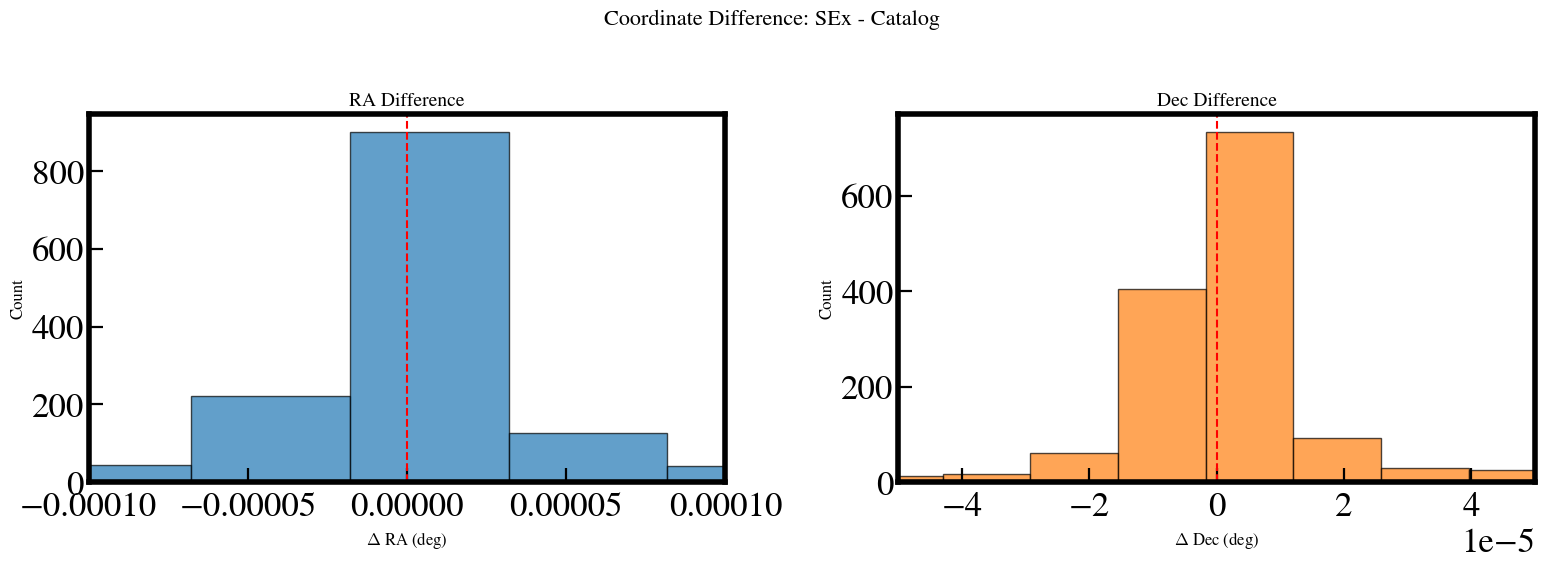

In [46]:
# =============================================================================
# Coordinate Difference Histogram: Matched Sources
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Coordinate Difference: SEx - Catalog', fontsize=16)

# RA difference
ax[0].hist(matched_F105W['ra'] - matched_Cat['RA'], bins=15, 
           color='tab:blue', edgecolor='black', alpha=0.7)
ax[0].set_title('RA Difference', fontsize=14)
ax[0].set_xlabel('$\Delta$ RA (deg)', fontsize=12)
ax[0].set_ylabel('Count', fontsize=12)
ax[0].set_xlim([-0.0001, 0.0001])
ax[0].axvline(0, ls='--', color='red', lw=1.5)

# Dec difference
ax[1].hist(matched_F105W['dec'] - matched_Cat['Dec'], bins=15, 
           color='tab:orange', edgecolor='black', alpha=0.7)
ax[1].set_title('Dec Difference', fontsize=14)
ax[1].set_xlabel('$\Delta$ Dec (deg)', fontsize=12)
ax[1].set_ylabel('Count', fontsize=12)
ax[1].set_xlim([-0.00005, 0.00005])
ax[1].axvline(0, ls='--', color='red', lw=1.5)

plt.tight_layout()
plt.show()


## 3) UnMatched Source

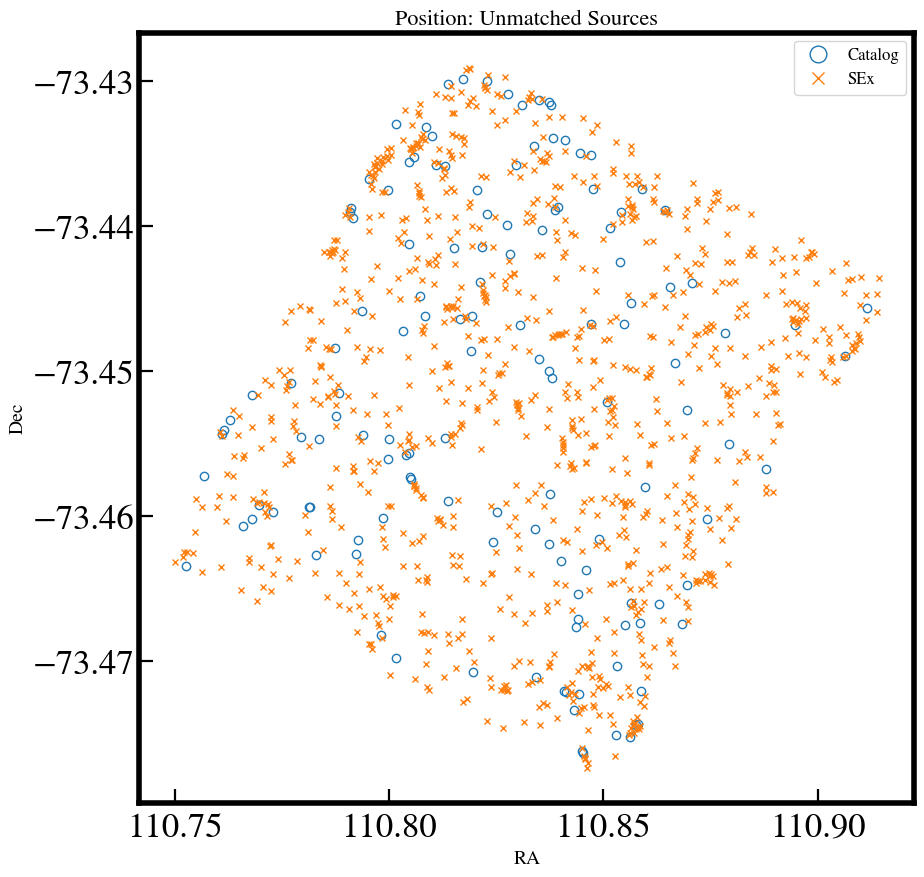

In [47]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Position: Unmatched Sources
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(unmatched_Cat['RA'], unmatched_Cat['Dec'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Catalog')
ax.plot(unmatched_F105W['ra'], unmatched_F105W['dec'],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')

ax.set_title('Position: Unmatched Sources', fontsize=16)
ax.set_xlabel('RA', fontsize=14)
ax.set_ylabel('Dec', fontsize=14)
ax.legend(markerscale=2, fontsize=12, handler_map=handler_map)
plt.show()


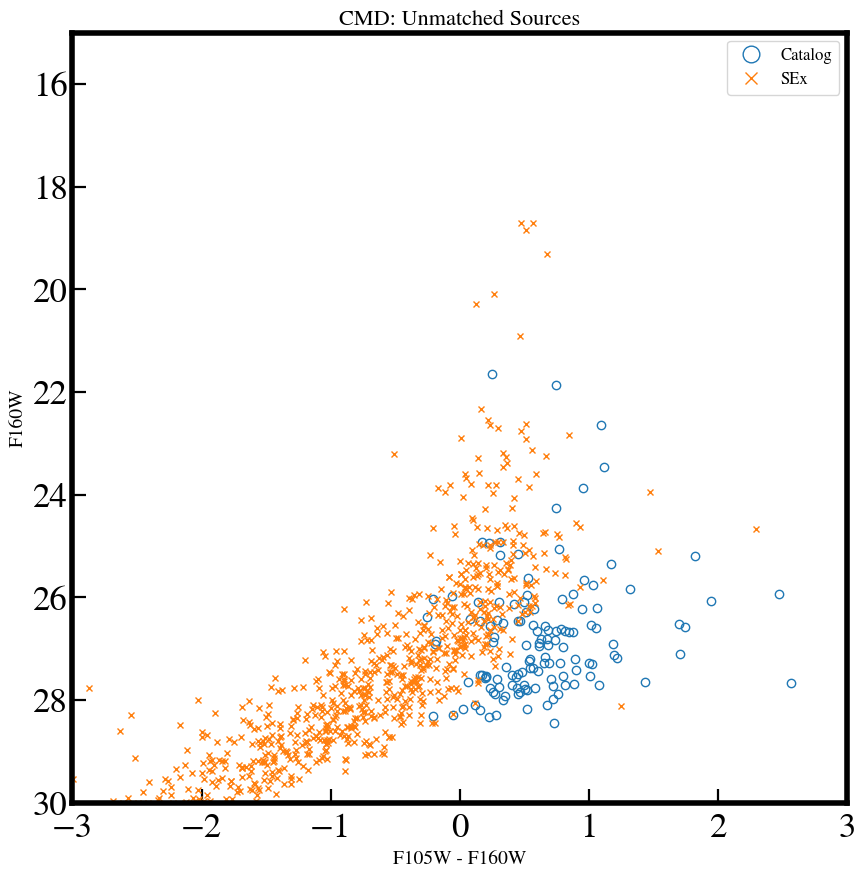

In [48]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# CMD: Unmatched Sources
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ax.plot(unmatched_Cat[f'{bands_catread[0]}_mag'] - unmatched_Cat[f'{bands_catread[1]}_mag'],
        unmatched_Cat[f'{bands_catread[1]}_mag'],
        marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Catalog')
ax.plot(unmatched_F105W['mag_iso'] - unmatched_F160W['mag_iso'],
        unmatched_F160W['mag_iso'],
        marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')

ax.set_title('CMD: Unmatched Sources', fontsize=16)
ax.set_xlabel(f'{bands[0]} - {bands[1]}', fontsize=14)
ax.set_ylabel(f'{bands[1]}', fontsize=14)
ax.set_xlim([-3, 3])
ax.set_ylim([30, 15])
ax.legend(markerscale=2, fontsize=12, handler_map=handler_map)
plt.show()


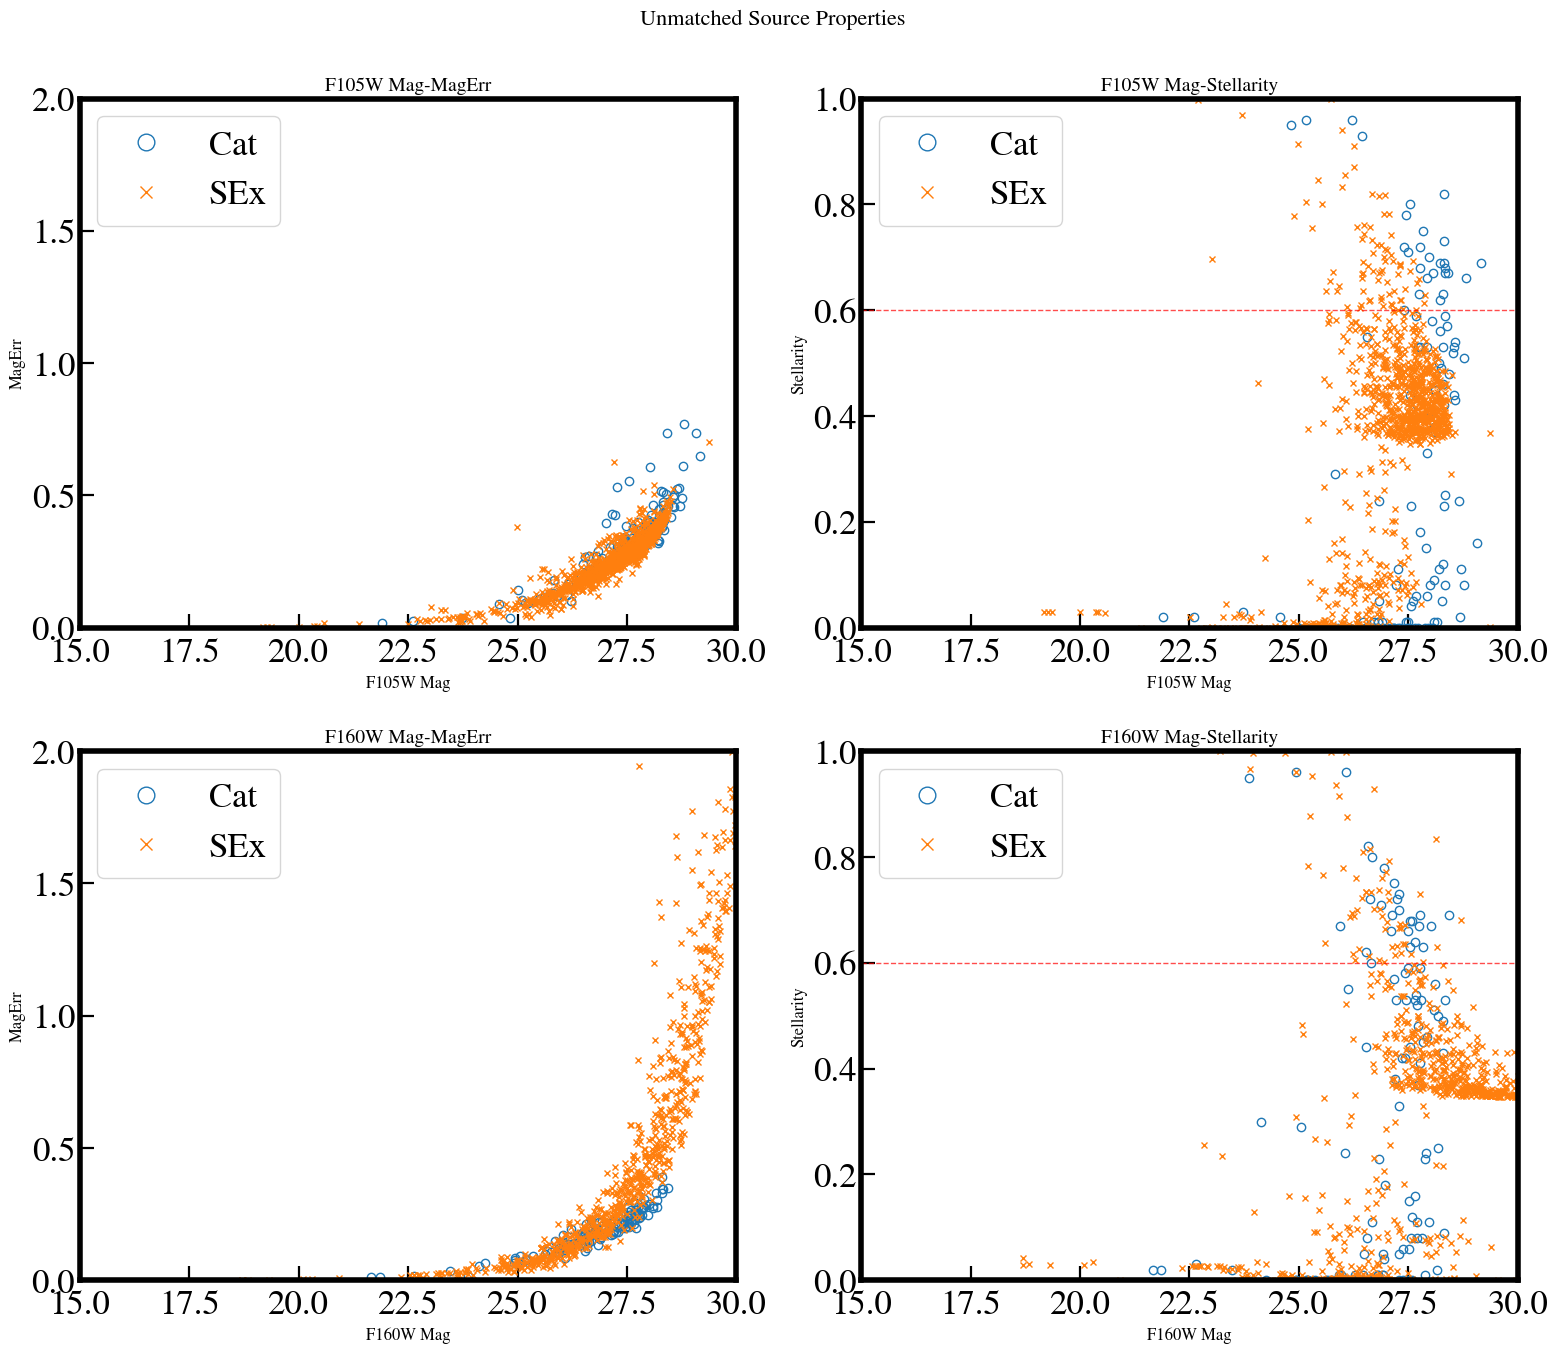

In [50]:
from matplotlib.legend_handler import HandlerLine2D
handler_map = {plt.Line2D: HandlerLine2D(marker_pad=0.3)}

# =============================================================================
# Unmatched Source Properties
# =============================================================================
fig, ax = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Unmatched Source Properties', fontsize=16)

# -----------------------------------------------------------------------------
# (0,0) F105W Mag-MagErr
# -----------------------------------------------------------------------------
ax[0, 0].plot(unmatched_Cat[f'{bands_catread[0]}_mag'], unmatched_Cat[f'{bands_catread[0]}_magerr'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[0, 0].plot(unmatched_F105W['mag_iso'], unmatched_F105W['merr_iso'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0, 0].set_title(f'{bands[0]} Mag-MagErr', fontsize=14)
ax[0, 0].set_xlabel(f'{bands[0]} Mag', fontsize=12)
ax[0, 0].set_ylabel('MagErr', fontsize=12)
ax[0, 0].set_xlim([15, 30])
ax[0, 0].set_ylim([0, 2])
ax[0, 0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (0,1) F105W Mag-Stellarity
# -----------------------------------------------------------------------------
ax[0, 1].plot(unmatched_Cat[f'{bands_catread[0]}_mag'], unmatched_Cat['stel'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[0, 1].plot(unmatched_F105W['mag_iso'], unmatched_F105W['cl'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[0, 1].set_title(f'{bands[0]} Mag-Stellarity', fontsize=14)
ax[0, 1].set_xlabel(f'{bands[0]} Mag', fontsize=12)
ax[0, 1].set_ylabel('Stellarity', fontsize=12)
ax[0, 1].set_xlim([15, 30])
ax[0, 1].set_ylim([0, 1])
ax[0, 1].axhline(0.6, ls='--', color='red', lw=1, alpha=0.7)
ax[0, 1].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1,0) F160W Mag-MagErr
# -----------------------------------------------------------------------------
ax[1, 0].plot(unmatched_Cat[f'{bands_catread[1]}_mag'], unmatched_Cat[f'{bands_catread[1]}_magerr'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[1, 0].plot(unmatched_F160W['mag_iso'], unmatched_F160W['merr_iso'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1, 0].set_title(f'{bands[1]} Mag-MagErr', fontsize=14)
ax[1, 0].set_xlabel(f'{bands[1]} Mag', fontsize=12)
ax[1, 0].set_ylabel('MagErr', fontsize=12)
ax[1, 0].set_xlim([15, 30])
ax[1, 0].set_ylim([0, 2])
ax[1, 0].legend(markerscale=2, handler_map=handler_map)

# -----------------------------------------------------------------------------
# (1,1) F160W Mag-Stellarity
# -----------------------------------------------------------------------------
ax[1, 1].plot(unmatched_Cat[f'{bands_catread[1]}_mag'], unmatched_Cat['stel'],
              marker='o', ms=6, mfc='none', mec='tab:blue', linestyle='None', label='Cat')
ax[1, 1].plot(unmatched_F160W['mag_iso'], unmatched_F160W['cl'],
              marker='x', ms=4, color='tab:orange', linestyle='None', label='SEx')
ax[1, 1].set_title(f'{bands[1]} Mag-Stellarity', fontsize=14)
ax[1, 1].set_xlabel(f'{bands[1]} Mag', fontsize=12)
ax[1, 1].set_ylabel('Stellarity', fontsize=12)
ax[1, 1].set_xlim([15, 30])
ax[1, 1].set_ylim([0, 1])
ax[1, 1].axhline(0.6, ls='--', color='red', lw=1, alpha=0.7)
ax[1, 1].legend(markerscale=2, handler_map=handler_map)

plt.tight_layout()
plt.show()


In [ ]:
# Create DS9 region files for visualization of source positions

def write_region_file(filename, coords, radius=20):
    """
    Write a DS9 region file marking sources at (x, y) coordinates with circles.
    
    Parameters:
        filename : str
            Output region file name.
        coords : pandas.DataFrame or np.ndarray
            DataFrame or array with columns 'x' and 'y'.
        radius : float
            Circle radius in pixels (default: 20).
    """
    with open(filename, 'w') as f:
        for idx, row in enumerate(coords):
            f.write(f'image;circle({row[0]:.2f}, {row[1]:.2f}, {radius}) \n')

# For unmatched_F105W and unmatched_F160W
src1 = np.column_stack((unmatched_F105W['x'], unmatched_F105W['y']))
src2 = np.column_stack((unmatched_F160W['x'], unmatched_F160W['y']))
all_src = np.vstack([src1, src2])
write_region_file('test1.reg', all_src, radius=20)

# For unmatched_Cat
src_cat = np.column_stack((unmatched_Cat['x'], unmatched_Cat['y']))
write_region_file('test2.reg', src_cat, radius=20)

# DS9 display: Region -> Load regions -> select 'test1.reg' or 'test2.reg'
